In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scripts.VectorFieldEmbedder import VectorFieldEmbedder

# ---- paths (from your code) ----
pos_file = "./data/s_curve/uniform/s_curve_noisy_hd_position_matrix.csv"
vel_file = "./data/s_curve/uniform/s_curve_noisy_hd_velocity_matrix.csv"
time_file = "./data/s_curve/uniform/s_curve_gt_latent_time_vector.csv"

# ---- load ----
X = pd.read_csv(pos_file).values        # (n_cells, high_dim)
V = pd.read_csv(vel_file).values        # (n_cells, high_dim)
t = pd.read_csv(time_file).values.squeeze()

print(X.shape, V.shape, t.shape)

/Users/jh/micromamba/envs/scvelo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(1000, 100) (1000, 100) (1000,)


In [2]:
def plot_quiver_stride(
    X,
    V,
    color=None,
    stride=30,
    arrow_scale=0.8,
    linewidth=1.5,
    figsize=(5, 4),
    cmap="viridis",
    show_axes=False,
):
    """
    Simple quiver plot with subsampling (stride), no colorbar.
    """
    idx = np.arange(0, X.shape[0], stride)

    Xs = X[idx]
    Vs = V[idx]

    # normalize vectors and rescale to visible length
    norms = np.linalg.norm(Vs, axis=1, keepdims=True) + 1e-8
    Vs_unit = Vs / norms
    Vs_plot = Vs_unit * arrow_scale

    fig, ax = plt.subplots(figsize=figsize)

    # scatter background
    if color is not None:
        ax.scatter(
            X[:, 0], X[:, 1],
            c=color,
            s=10,
            alpha=0.3,
            cmap=cmap
        )
    else:
        ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.3)

    # quiver arrows
    ax.quiver(
        Xs[:, 0], Xs[:, 1],
        Vs_plot[:, 0], Vs_plot[:, 1],
        angles="xy",
        scale_units="xy",
        scale=3.0,
        width=0.004,
        headwidth=4,
        headlength=6,
        headaxislength=5,
        linewidth=linewidth,
        alpha=0.9,
        color="black"
    )

    ax.set_aspect("equal")
    if not show_axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

[PCA] Applying PCA (input dim = 100) …
[PCA] TruncatedSVD → 30 components …
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …


[TPS] Fitting geometry spline …


[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …


[Init] Done.


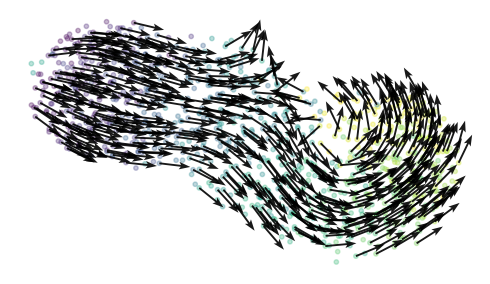

In [3]:
# emb = VectorFieldEmbedder(X, V, knn_k=15,
#                           dist_method="euclidean", method="umap",
#                           embed_kwargs={"n_neighbors":15,
#                                          "min_dist":0.3},
#                           dof=20)

emb = VectorFieldEmbedder(
    X,
    V,
    knn_k=15,
    dist_method="phase",          # phase-aware distance
    alpha=0,
    method="umap",
    embed_kwargs={
        "n_neighbors": 15,
        "min_dist": 0.3,
    },
    dof=20,
)

emb.initialize_embedding(42)

plot_quiver_stride(
    X=emb.X_emb,
    V=emb.V_emb,
    color=t,
    stride=2,
    arrow_scale=2
)

Running FlowMap with phase alpha = 0.0
[PCA] Applying PCA (input dim = 100) …
[PCA] TruncatedSVD → 30 components …
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …


[TPS] Fitting geometry spline …


[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …


[Init] Done.


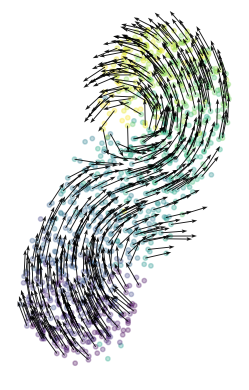

Running FlowMap with phase alpha = 0.25
[PCA] Applying PCA (input dim = 100) …
[PCA] TruncatedSVD → 30 components …
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …


[TPS] Fitting geometry spline …


[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …


[Init] Done.


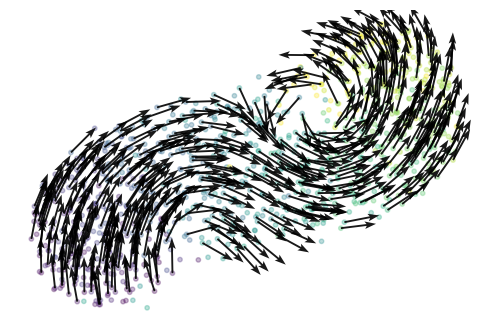

Running FlowMap with phase alpha = 0.5
[PCA] Applying PCA (input dim = 100) …
[PCA] TruncatedSVD → 30 components …
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …


[TPS] Fitting geometry spline …


[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …


[Init] Done.


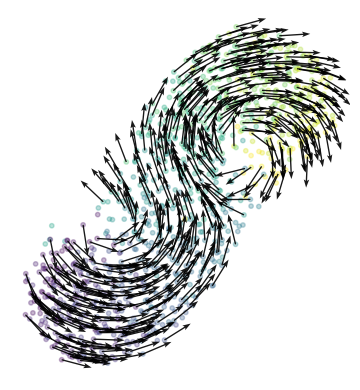

Running FlowMap with phase alpha = 0.75
[PCA] Applying PCA (input dim = 100) …
[PCA] TruncatedSVD → 30 components …
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …


[TPS] Fitting geometry spline …


[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …


[Init] Done.


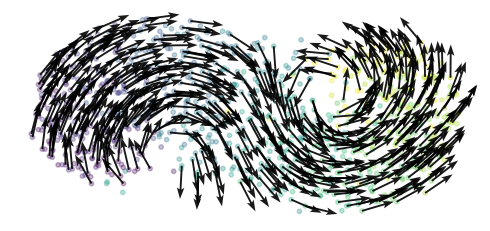

Running FlowMap with phase alpha = 1.0
[PCA] Applying PCA (input dim = 100) …
[PCA] TruncatedSVD → 30 components …
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …


[TPS] Fitting geometry spline …


[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …


[Init] Done.


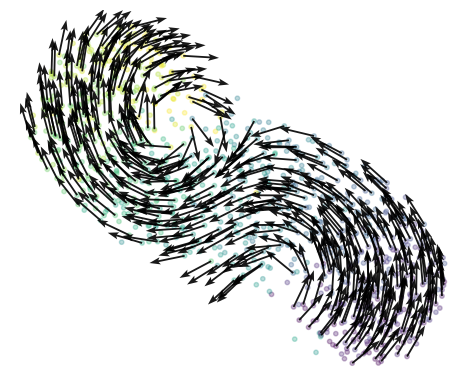

In [4]:
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]

for alpha in alphas:
    print(f"Running FlowMap with phase alpha = {alpha}")

    emb = VectorFieldEmbedder(
        X,
        V,
        knn_k=30,
        dist_method="phase",          # phase-aware distance
        alpha=alpha,
        method="umap",
        embed_kwargs={
            "n_neighbors": 30,
            "min_dist": 0.3,
        },
        dof=20,
    )

    emb.initialize_embedding(42)

    plot_quiver_stride(
        X=emb.X_emb,
        V=emb.V_emb,
        color=t,
        stride=2,
        arrow_scale=2,
    )

computing neighbors


    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)


computing velocity graph (using 1/18 cores)
or disable the progress bar using `show_progress_bar=False`.


    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


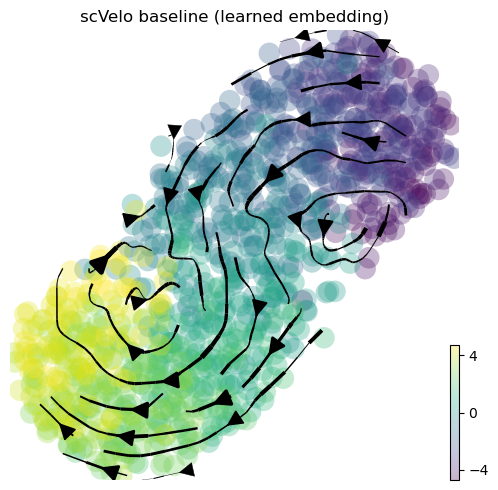

In [5]:
import anndata
import scvelo as scv
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# CREATE ANN DATA
# -----------------------------
adata = anndata.AnnData(X.copy())

adata.layers["position"] = X.copy()
adata.layers["velocity"] = V.copy()
adata.obs["color"] = t

# -----------------------------
# NEIGHBORS + EMBEDDING
# -----------------------------
scv.pp.neighbors(
    adata,
    n_neighbors=15,
    use_rep="X",
)

# IMPORTANT: embedding comes from scanpy, not scvelo
sc.tl.umap(adata, min_dist=0.3)

# -----------------------------
# VELOCITY GRAPH + EMBEDDING
# -----------------------------
scv.tl.velocity_graph(
    adata,
    xkey="position",
    vkey="velocity",
)

scv.tl.velocity_embedding(
    adata,
    basis="umap",
)

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))
scv.pl.velocity_embedding_stream(
    adata,
    basis="umap",
    color="color",
    cmap="viridis",
    ax=ax,
    show=False,
    density=0.6,
    arrow_size=2.5,
    linewidth=2.0,
)
ax.set_title("scVelo baseline (learned embedding)")
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.show()